# Normal Equation (Solving approach 1 for Linear Regression)

In [43]:
import numpy as np
import matplotlib.pyplot as plt

x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

Text(0, 0.5, 'y')

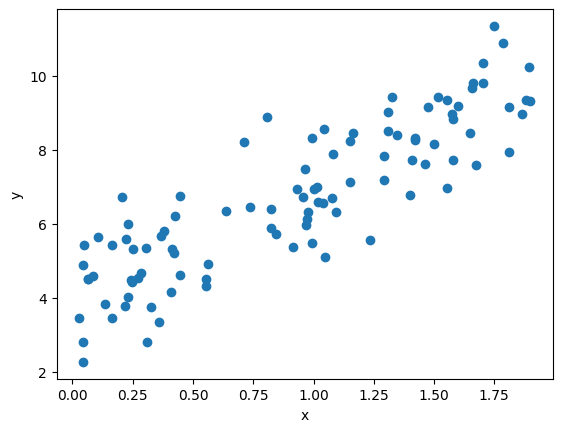

In [44]:
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")

In [22]:
x_b = np.c_[np.ones((100,1)), x]      #add x0 = 1 to every instance
theta_best = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)

In [23]:
theta_best  #values are close to 4 and 3 , but not exact, due to added noise with y

array([[4.08851093],
       [2.98498931]])

 ##  Making Prediction 

In [27]:
x_new = np.array([[0], 
                  [2]])
x_new_b = np.c_[np.ones((2,1)), x_new]

y_predict = x_new_b.dot(theta_best)
y_predict

array([[ 4.08851093],
       [10.05848954]])

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(14.0))

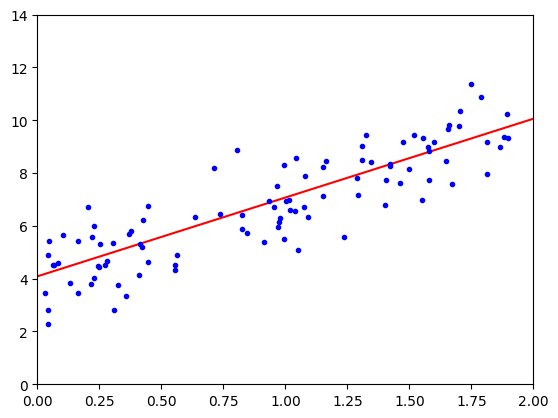

In [45]:
plt.plot(x_new, y_predict, "r-")
plt.plot(x, y, "b.")
plt.axis([0, 2, 0, 14])            #plt.axis([xmin, xmax, ymin, ymax])

# Linear Regression — Making Predictions

## 1. We Already Trained the Model

Earlier, we used the **Normal Equation** to find the best parameters:

```python
theta_best
```

The result was approximately:

```text
[[4.08851093],
 [2.98498931]]
```

Therefore:

```text
θ₀ ≈ 4.0885
θ₁ ≈ 2.9850
```

Our learned linear regression equation is:

$$
\hat{y} = \theta_0 + \theta_1x
$$

So approximately:

$$
\hat{y} = 4.0885 + 2.985x
$$

The original data was generated approximately using:

$$
y = 4 + 3x + noise
$$

Therefore, the model learned values close to the original parameters `4` and `3`.

---

# 2. We Want to Predict New Values

Suppose we want to make predictions for:

```text
x = 0
x = 2
```

We create:

```python
x_new = np.array([[0],
                  [2]])
```

This means:

```text
x_new =

[[0],
 [2]]
```

There are:

* **2 samples**
* **1 feature**

So the shape is:

```python
x_new.shape
```

```text
(2, 1)
```

The rows represent individual samples:

```text
Sample 1 → x = 0
Sample 2 → x = 2
```

---

# 3. Why Do We Use `[[0], [2]]` Instead of `[0, 2]`?

In machine learning, data is generally represented as a **2D array**.

The convention is:

```text
Rows    → samples
Columns → features
```

Therefore:

```python
np.array([[0],
          [2]])
```

means:

```text
2 samples × 1 feature
```

Whereas:

```python
np.array([0, 2])
```

is a 1D array with shape:

```text
(2,)
```

For this matrix-based calculation, we want the 2D representation.

---

# 4. Creating `x_new_b`

The next line is:

```python
x_new_b = np.c_[np.ones((2, 1)), x_new]
```

This might look confusing, so let's break it down.

First:

```python
np.ones((2, 1))
```

creates:

```text
[[1],
 [1]]
```

We then concatenate this column with `x_new`.

So:

```text
[[1],    [[0],       [[1, 0],
 [1]]     [2]]   →    [1, 2]]
```

Therefore:

```text
x_new_b =

[[1, 0],
 [1, 2]]
```

---

# 5. Why Do We Add the Column of `1`s?

Our linear regression equation is:

$$
\hat{y} = \theta_0 + \theta_1x
$$

We want to express this using matrix multiplication.

We can write:

$$
\hat{y}
=
\begin{bmatrix}
1 & x
\end{bmatrix}
\begin{bmatrix}
\theta_0 \\
\theta_1
\end{bmatrix}
$$

Matrix multiplication gives:

$$
1\theta_0 + x\theta_1
$$

which is:

$$
\theta_0 + \theta_1x
$$

This is exactly our linear regression equation.

Therefore, the `1` is there to handle the **intercept/bias parameter `θ₀`**.

Our input becomes:

```text
x_new_b =

[[1, 0],
 [1, 2]]
```

The first column contains `1`s for the intercept.

The second column contains the actual feature `x`.

---

# 6. Understanding `x_new_b`

We have:

```text
x_new_b =

[[1, 0],
 [1, 2]]
```

Each row represents one sample.

### First sample

```text
[1, 0]
```

This represents:

```text
x = 0
```

The calculation will be:

$$
1\theta_0 + 0\theta_1
$$

which gives:

$$
\theta_0
$$

---

### Second sample

```text
[1, 2]
```

This represents:

```text
x = 2
```

The calculation will be:

$$
1\theta_0 + 2\theta_1
$$

which gives:

$$
\theta_0 + 2\theta_1
$$

---

# 7. Making the Predictions

Now we perform the actual prediction:

```python
y_predict = x_new_b.dot(theta_best)
```

We have:

```text
x_new_b =

[[1, 0],
 [1, 2]]
```

and:

```text
theta_best =

[[4.0885],
 [2.9850]]
```

Therefore, we perform:

$$
\begin{bmatrix}
1 & 0 \\
1 & 2
\end{bmatrix}
\begin{bmatrix}
4.0885 \\
2.9850
\end{bmatrix}
$$

---

## First Prediction

For:

```text
x = 0
```

we calculate:

$$
1(4.0885) + 0(2.9850)
$$

Therefore:

$$
\hat{y} \approx 4.0885
$$

So:

```text
x = 0
```

produces approximately:

```text
y = 4.09
```

---

## Second Prediction

For:

```text
x = 2
```

we calculate:

$$
1(4.0885) + 2(2.9850)
$$

$$
= 4.0885 + 5.9700
$$

$$
\approx 10.0585
$$

So:

```text
x = 2
```

produces approximately:

```text
y = 10.06
```

---

# 8. What Does `y_predict` Contain?

The result is approximately:

```text
y_predict =

[[ 4.08851093],
 [10.05848954]]
```

This means:

```text
Prediction 1 → x = 0 → y ≈ 4.09

Prediction 2 → x = 2 → y ≈ 10.06
```

In plain English:

> According to our trained model, when `x = 0`, the predicted `y` is approximately `4.09`. When `x = 2`, the predicted `y` is approximately `10.06`.

---

# 9. Plotting the Predictions

The book then plots the predictions:

```python
plt.plot(x_new, y_predict, "r-")
```

Here:

```text
x_new      → [0, 2]
y_predict  → [4.09, 10.06]
```

So Matplotlib has two points:

```text
(0, 4.09)
(2, 10.06)
```

The `"r-"` means:

```text
r → red
- → solid line
```

Therefore, Matplotlib draws a **red line** connecting those points.

This red line represents our learned linear regression model.

---

# 10. Plotting the Original Training Data

The next line is:

```python
plt.plot(x, y, "b.")
```

This plots the original training data.

Here:

```text
x → original input values
y → original target values
```

The `"b."` means:

```text
b → blue
. → dot/point
```

So the original observations appear as **blue dots**.

---

# 11. Understanding the Final Graph

The final graph contains two things.

## Blue Dots

The blue dots are the **actual training observations**:

```text
(x, y)
```

They contain random noise.

---

## Red Line

The red line is the **linear regression model**:

$$
\hat{y} = \theta_0 + \theta_1x
$$

Using our learned parameters:

$$
\hat{y} \approx 4.0885 + 2.985x
$$

So:

```text
🔵 Blue dots → actual observed data

🔴 Red line  → model's learned relationship
```

---

# 12. Why Doesn't the Red Line Pass Through Every Blue Dot?

Because the data contains **noise**.

The data was generated using:

```python
y = 4 + 3*x + np.random.randn(100, 1)
```

The important part is:

```python
np.random.randn(100, 1)
```

This generates random Gaussian noise.

Therefore, the actual data is approximately:

$$
y = 4 + 3x + noise
$$

The model is trying to learn the underlying relationship:

$$
\hat{y} \approx 4.09 + 2.985x
$$

Therefore, the blue points are scattered around the red line.

The red line is **not supposed to pass through every point**.

---

# 13. What Does `plt.axis()` Do?

The code:

```python
plt.axis([0, 2, 0, 14])
```

controls the visible boundaries of the graph.

The format is:

```text
[x_min, x_max, y_min, y_max]
```

Therefore:

```text
x_min = 0
x_max = 2

y_min = 0
y_max = 14
```

So the graph displays:

```text
x-axis: 0 → 2

y-axis: 0 → 14
```

This has **nothing to do with training or prediction**.

It only controls how the graph is displayed.

---

# 14. Can We Predict Only One Value?

Yes.

We don't have to provide two values such as:

```python
x_new = np.array([[0],
                  [2]])
```

We can predict for just one value.

For example:

```python
x_new = np.array([[5]])
```

This means:

```text
One sample
One feature

x = 5
```

Then:

```python
x_new_b = np.c_[np.ones((1, 1)), x_new]

y_predict = x_new_b.dot(theta_best)
```

Now:

```text
x_new_b =

[[1, 5]]
```

The prediction becomes:

$$
\hat{y} = 1\theta_0 + 5\theta_1
$$

Using our parameters:

$$
\hat{y}
=
4.0885 + 5(2.985)
$$

$$
\hat{y} \approx 19.01
$$

So the model predicts approximately:

```text
x = 5 → y ≈ 19.01
```

---

# 15. The Complete Prediction Process

```text
                 TRAINING
                    │
                    ▼
          Original training data
                x and y
                    │
                    ▼
             Normal Equation
                    │
                    ▼
              theta_best
             ┌──────┴──────┐
             │             │
          θ₀ ≈ 4.09     θ₁ ≈ 2.98
             │             │
             └──────┬──────┘
                    │
                    ▼
              TRAINED MODEL
                    │
                    │
             "Now predict
              new values"
                    │
                    ▼
              x_new = [[0],
                       [2]]
                    │
                    ▼
           Add column of 1s
                    │
                    ▼
             x_new_b = [[1, 0],
                         [1, 2]]
                    │
                    ▼
         x_new_b · theta_best
                    │
                    ▼
               y_predict
              [[4.09],
               [10.06]]
                    │
                    ▼
               PREDICTIONS
```

---

# 16. Training vs Prediction

This distinction is extremely important.

## Training

During training, we use the existing data to learn the parameters:

$$
(x, y) \rightarrow \theta
$$

In this example:

```text
Training data
     ↓
Normal Equation
     ↓
theta_best
```

---

## Prediction

After the model has learned its parameters, we can give it new inputs:

$$
x_{new} \rightarrow \hat{y}
$$

In this example:

```text
x_new
  ↓
Add intercept column
  ↓
x_new_b
  ↓
x_new_b · theta_best
  ↓
y_predict
```

---

# 17. The Big Picture

The fundamental workflow is:

```text
TRAIN
  │
  ▼
Training Data
(x, y)
  │
  ▼
Learning Algorithm
  │
  ▼
Learn Parameters
θ₀, θ₁
  │
  ▼
Trained Model
  │
  ▼
Give New Input
x_new
  │
  ▼
Make Prediction
ŷ
```

The key idea is:

> **Train a model → obtain learned parameters → give it new data → get predictions.**


# Implementing it by Sci-kit Learn

In [50]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()     #lin_reg as ML Model Object

lin_reg.fit(x, y)   #learn the relation of x and y from the training data

lin_reg.intercept_, lin_reg.coef_

(array([3.91768387]), array([[3.04975201]]))

In [51]:
lin_reg.predict(x_new)

array([[ 3.91768387],
       [10.01718788]])